<a href="https://colab.research.google.com/github/BryanStats/-Correlation-analysis-and-data-visualization-on-heart-attacks/blob/main/T_mobile_Tuesdays_DataScrapping_LDA_BERT_2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Topic Modeling on T-Mobile Tuesdays Deals**
## By Jennifer Mac & Bryan Ramirez

This project analyzes data from T-Mobile Tuesdays, a weekly promotion offered by T-Mobile, an American wireless network operator. Every Tuesday, T-Mobile members receive discounts on 3 to 7 randomly selected items, ranging from fast food deals to high-end brands like Adidas.


Given that T-Mobile operates at a higher price point than competing carriers, this project aims to evaluate the practical value of its membership perks by applying topic modeling to categorize and analyze the distribution of weekly discount offers. By determining what proportion of offers fall into each category, we can estimate the percentage of discounts a typical subscriber would realistically utilize.


For instance, if food-related offers account for 60% of all discounts and clothing accounts for 5%, a subscriber who redeems only food and clothing discounts could still take advantage of up to 65% of all available offers.


Data was collected from r/TMobileTuesdays, a Reddit community in which members share and request unused discount codes on a weekly basis, with archived posts dating back to 2016. Data collection was performed using Arctic Shift (arctic-shift.photon-reddit.com), a third-party tool designed for deep archiving and research of Reddit data.

# Step 0 – Setup

Install dependencies and import all libraries used throughout the notebook.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install thefuzz python-Levenshtein
!pip install sentence-transformers
!python -m spacy download en_core_web_md

import re
import ast
import math
import time
import spacy
import requests
import numpy as np
import pandas as pd
from nltk import ngrams
from thefuzz import fuzz
from thefuzz import process
from itertools import combinations
from rapidfuzz import process, fuzz
from nltk.tokenize import word_tokenize
from collections import Counter, defaultdict
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 48.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Step 1 – Fetch Raw Reddit Comments (DataScrapping)

## 1a - Get posts

Fetch the list of posts from r/TMobileTuesdays using the Arctic Shift API

In [2]:
# Step 1: Get posts (your working code)
url = 'https://arctic-shift.photon-reddit.com/api/posts/search'
params = {'subreddit': 'TMobileTuesdays', 'limit': 100}
response = requests.get(url, params=params)
data = response.json()

## 1b: For each post, fetch its comments

Paginate through the latest post and collect all top-level comments.

In [3]:
all_data = []

for post in data['data']:
    post_id = post.get('id')
    title = post.get('title', '')[45:]
    num = post.get('num_comments', 0)
    comments_url = 'https://arctic-shift.photon-reddit.com/api/comments/search'

    all_comments = []
    before = None
    while True:
        comments_params = {'link_id': post_id,
                           'limit': 100,}
        if before:
            comments_params['before'] = before
        comments_response = requests.get(comments_url, params=comments_params)

        if comments_response.status_code != 200:
            break
        comments_data = comments_response.json()

        if not comments_data or not comments_data.get('data'):
            break
        batch = comments_data['data']
        all_comments.extend(batch)

        print(f"  Fetched {len(all_comments)} comments so far...")

        if len(batch) < 100:
            break

        # Use oldest comment's created_utc as cursor
        before = min(c['created_utc'] for c in batch)
        time.sleep(0.3)

    # Only keep top-level comments
    comments = [c.get('body', '')
                for c in all_comments
                if c.get('parent_id', '').startswith('t3_')]

    all_data.append({
        'date': title,
        'num_com': num,
        'comments': comments
    })

  Fetched 87 comments so far...
  Fetched 100 comments so far...
  Fetched 200 comments so far...
  Fetched 216 comments so far...
  Fetched 75 comments so far...
  Fetched 100 comments so far...
  Fetched 184 comments so far...
  Fetched 100 comments so far...
  Fetched 200 comments so far...
  Fetched 300 comments so far...
  Fetched 400 comments so far...
  Fetched 432 comments so far...
  Fetched 100 comments so far...
  Fetched 200 comments so far...
  Fetched 261 comments so far...
  Fetched 100 comments so far...
  Fetched 176 comments so far...
  Fetched 100 comments so far...
  Fetched 200 comments so far...
  Fetched 300 comments so far...
  Fetched 345 comments so far...
  Fetched 100 comments so far...
  Fetched 200 comments so far...
  Fetched 300 comments so far...
  Fetched 400 comments so far...
  Fetched 500 comments so far...
  Fetched 600 comments so far...
  Fetched 700 comments so far...
  Fetched 800 comments so far...
  Fetched 900 comments so far...
  Fetched 10

Save raw scraped data to Google Drive as an Excel file.

In [6]:
df_raw = pd.DataFrame(all_data)
df_raw.to_excel("/content/drive/MyDrive/Stat_653/Data_Files/all_data.xlsx", index=False)

# Step 2 – Creating the T-Mobile Dataset

## 2a – Load Raw Data and Parse Comments
Load the saved Excel file and convert the flattened comment strings back into Python lists.

In [8]:
def parse_comments(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and not x.endswith(']') and not x.endswith("']"):
            x = x + "']"
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            return [x]
    return x

df_raw = pd.read_excel("/content/drive/MyDrive/Stat_653/Data_Files/all_data.xlsx")
df_raw['comments'] = df_raw['comments'].apply(parse_comments)
df = df_raw.copy()

## 2b – Define Stopwords
Build the custom stopword list used to filter noise from Reddit comments.

In [9]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

new_stopwords = set(stopwords.words('english'))         # adding custom words vvv
new_stopwords.update(['dm', 'pm', 'lmk', 'please', 'need', 'anyone', 'somebody',
                  'trade', 'comment', 'plz', 'free', 'bogo', 'if', 'use', 'got',
                  'using', 'used', 'code', 'codes', 'zelle', 'agc', 'venmo',
                  'looking', 'thanks', 'thank', 'you', 'enjoy', 'com', 'taken',
                  'want', 'join', 'tmobile', 'message', 'pp', 'vmo', 'interested',
                  'extra', 'spare', 'reply', 'stating', 'find', 'already', 'get',
                  'available', 'selling', 'sell', 'buy', 'buying', 'mobile',
                  'share', 'available', 'tonight', 'send', 'thanks', 'one', 'hi',
                  'following', 'shipping', 'iso', 'offer', 'gifts', 'cashapp',
                  'someone', 'else', 'via', 'activated', 'last', 'details',
                  'prevent', 'people', 'give', 'away', 'open', 'price',
                  'negotiations', 'vnmo', 'expire', 'expires', 'soon', 'let',
                  'know', 'update', 'trades', 'complete', 'preferred', 'notifications',
                  'update', 'gone', 'next', 'week', 'check', 'chat', 'well', 'try',
                  'check', 'chat', 'disable', 'adblocker', 'even', 'would',
                  'like', 'gonna', 'expired', 'wasted', 'payment', 'required',
                  'come', 'serve', 'proof', 'previous', 'appreciate', 'multiple',
                  'needed','first', 'per', 'month', 'someone\'s', 'help', 'done',
                  'past', 'years', 'safe', 'works', 'tomorrow', 'change', 'email',
                  'password', 'ios', 'devices', 'matters', 'much', 'appreciated',
                  'cash app', 'cashapp', 'custom', 'applicable', 'tax',
                  'bread sticks sauce', 'removed', 'pls', 'deleted',
                  'magnetic photo strips', 'android users'])
new_stopwords -= {'in', 'the'}


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 2c – Define Known Brands and Manual Aliases
List all T-Mobile Tuesday brands and define manual aliases for common abbreviations and misspellings.

In [10]:
known_brands = [
    'shell', 'crocs', 'little caesars', 'personal creations', 'pizza hut',
    'bouqs', 'atom ticket', 'jack in the box', 'kfc', 'mlb', 'mls',
    'kung fu tea', 'nogu', 'popeyes', 'amc', 'legoland', 'funko', 'adidas',
    'new era', 'nobull', 'hello fresh', 'tropical smoothie cafe', 'accuweather',
    'factor', 'magazine', 'firehouse subs', 'daily burn', 'readmio', 'shutterfly',
    'laura geller', 'cvs', 'yankee candle', 'wendys', 'webtoon', 'uber', 'wingstop',
    'qdoba', 'mgm', 'burger king', 'costco', 'panera', 'ifit', 'all birds',
    'shake shack', 'foco', 'sams club', 'crunch labs', 'lazy dog', 'blue dolphin',
    'reebok', 'walgreens', 'fathead', 'home chef', 'rover', 'puma', 'teepublic',
    'panda express', 'hey dude', 'auntie annes', 'bjs','dollar shave club',
    'dave buster']

brand_aliases = {
    'gift card':      ['gc'],
    'firehouse subs': ['fh', 'fire house', 'firehouse'],
    'shell':          ['gas', 'petrol'],
    'auntie annes':   ['auntie annie', 'annes', 'aunt'],
    'atom ticket':    ['atom', 'movie ticket', 'michael jackson', 'smurfs'],
    'magazine':       ['mags', 'magscom'],
    'jack in the box':['jitb', 'jib', 'jb', 'jackinthebox', 'jack box', 'jacks',
                       'jack in the', 'jack in box', 'jacknbox', 'jack'],
    'bouqs':          ['flowers', 'bouquet', 'bouquets', 'floral'],
    'photo books':    ['photobook', 'photobooks', 'photo book'],
    'free prints':    ['freeprints', 'free print'],
    'hello fresh':    ['hellofresh'],
    'all birds':      ['allbirds'],
    'sams club':      ["sam's club", 'samsclub', 'club'],
    'burger king':    ['bk'],
    'little caesars': ['little c', 'lil c', 'lc', 'slices n stix'],
    'kfc':            ['kentucky fried chicken'],
    'factor':         ['factor75'],
    'capital one':    ['handcrafted beverage qr', 'beverage qr'],
    'door dash':      ['dash pass']
}


## 2d – Brand Alias Helper Functions
Auto-generate suffix aliases from multi-word brand names and apply alias normalization to raw text.

In [11]:
def add_suffix_aliases(known_brands, brand_aliases):
    for brand in known_brands:
        words = brand.split()
        if len(words) < 2:
            continue
        for i in range(1, len(words)):
            suffix = ' '.join(words[i:])
            # only add if not already an alias for something else
            already_mapped = any(suffix in aliases for aliases in brand_aliases.values())
            if not already_mapped and suffix not in known_brands:
                if brand not in brand_aliases:
                    brand_aliases[brand] = []
                if suffix not in brand_aliases[brand]:
                    brand_aliases[brand].append(suffix)
    return brand_aliases

brand_aliases = add_suffix_aliases(known_brands, brand_aliases)

def apply_brand_aliases(text):
    if not isinstance(text, str):
        return text
    for canonical, aliases in sorted(brand_aliases.items(), key=lambda x: len(x[0]), reverse=True):
        # Skip if the canonical brand is already in the text
        if re.search(rf'\b{re.escape(canonical)}\b', text, re.IGNORECASE):
            continue  # already present, don't replace partial aliases
        for alias in sorted(aliases, key=len, reverse=True):
            if alias.lower() not in canonical.lower():
                text = re.sub(rf'\b{re.escape(alias)}\b', canonical, text, flags=re.IGNORECASE)
            else:
                text = re.sub(
                    rf'\b{re.escape(alias)}\b(?!\s*{re.escape(canonical[len(alias):].strip())})',
                    canonical, text, flags=re.IGNORECASE
                )
    return text


## 2e – Comment Processing
Strip promo codes, URLs, and numbers from comments. Extract brand context around code mentions.

In [12]:
def remove_after_last_code(comment):
    matches = list(re.finditer(r'\b(?:[A-Za-z0-9]{2,}-)+[A-Za-z0-9]{2,}\b|\b[A-Za-z0-9]*[0-9][A-Za-z0-9]{3,}\b', comment, re.IGNORECASE))
    if not matches:
        return comment
    last_match = matches[-1]
    return comment[:last_match.end()]

def process_comment(comment):
    if not isinstance(comment, str):
        return None
    comment = apply_brand_aliases(comment)
    comment = re.sub(r'http\S+|www\.\S+', ',', comment)
    comment = re.sub(r'\b\d+\b', '', comment)  # remove standalone numbers
    normalized = comment.replace('\r\n', '\n').replace('\r', '\n').replace('\\n', '\n')

    code_pattern = r'\b(?:[A-Za-z0-9]{2,}-)+[A-Za-z0-9]{2,}\b|\b[A-Za-z0-9]*[0-9][A-Za-z0-9]{3,}\b'

    is_structured = re.search(r'\bmlb\b', comment, re.IGNORECASE) or normalized.count('\n') >= 3
    has_promo_code = bool(re.search(code_pattern, comment, re.IGNORECASE))

    if is_structured or has_promo_code:
        cleaned = remove_after_last_code(comment)
        cleaned = re.sub(code_pattern, ',', cleaned, flags=re.IGNORECASE)
        cleaned = re.sub(r'[^a-zA-Z\s,]', ',', cleaned)
        cleaned = re.sub(r'[,\s]*,[,\s]*', ', ', cleaned)
        cleaned = cleaned.strip(', ')
        chunks = [c.strip() for c in cleaned.split(',')]
        filtered = []
        for chunk in chunks:
            words = [w for w in chunk.split() if w.lower() not in new_stopwords]
            if words:
                filtered.append(' '.join(words))
        return [', '.join(filtered)] if filtered else None

    # ↓ replace everything below this line
    mentions_code = list(re.finditer(r'\bcodes?\b', comment, re.IGNORECASE))
    if mentions_code:
        results = []
        for match in mentions_code:
            words = comment[:match.start()].split()
            collected = []
            for word in reversed(words):
                if len(collected) >= 5:
                    break
                potential = [word] + collected
                potential_str = ' '.join(potential).lower()
                part_of_brand = any(brand.startswith(potential_str) or potential_str in brand
                                   for brand in known_brands)
                if word.lower() in new_stopwords and not part_of_brand:
                    break
                collected.insert(0, word)
            if collected:
                result = ' '.join(collected).strip()
                # trim to longest matching brand name found within result
                for brand in sorted(known_brands, key=len, reverse=True):
                    if result.lower().endswith(brand):
                        result = brand
                        break
                    if brand in result.lower():
                        result = brand
                        break
                results.append(result)

        return results if results else None  # indented inside the if block
    return None


## 2f – Brand Normalization Helpers
Functions to extract n-gram brand candidates, normalize tokens to canonical brand names, and deduplicate repeated phrases.

In [13]:
def extract_brand_candidates(tokens, min_count=3):
    all_ngrams = [' '.join(g) for n in (2, 3) for g in ngrams(tokens, n)]
    return {p for p, c in Counter(all_ngrams).items() if c >= min_count}

def normalize_to_candidate(token, candidates):
    token_lower = token.lower().strip()
    # skip if already a known brand
    if token_lower in known_brands:
        return token_lower
    for candidate in sorted(candidates, key=len, reverse=True):
        if token_lower.startswith(candidate):
            return candidate
    return token_lower


def deduplicate_phrase(token):
    words = token.split()
    for length in range(1, len(words) // 2 + 1):
        phrase = words[:length]
        if all(words[i:i+length] == phrase for i in range(0, len(words), length)):
            return ' '.join(phrase)
    # check if token with last word removed matches a known brand
    if len(words) > 1:
        without_last = ' '.join(words[:-1]).lower()
        if without_last in known_brands:
            return without_last
    return token

def generate_brand_aliases(known_brands, min_words=1):
    """Auto-generate aliases from substrings of known brand names"""
    auto_aliases = {}
    for brand in known_brands:
        words = brand.split()
        if len(words) < 2:
            continue  # skip single word brands
        # generate all contiguous substrings of words
        for start in range(len(words)):
            for end in range(start + min_words, len(words)):  # exclude full brand name
                substring = ' '.join(words[start:end])
                if substring not in auto_aliases:
                    auto_aliases[substring] = brand
    return auto_aliases

auto_brand_aliases = generate_brand_aliases(known_brands)

def normalize_to_brand(token):
    token_lower = token.lower().strip()

    # check manual aliases first
    for canonical, aliases in brand_aliases.items():
        for alias in sorted(aliases, key=len, reverse=True):
            if token_lower == alias or token_lower.startswith(alias):
                return canonical

    # check exact brand match
    if token_lower in known_brands:
        return token_lower

    # check if token starts with a known brand
    for brand in sorted(known_brands, key=len, reverse=True):
        if token_lower.startswith(brand):
            return brand

    # check auto-generated aliases
    for alias, brand in sorted(auto_brand_aliases.items(), key=lambda x: len(x[0]), reverse=True):
        if token_lower == alias or token_lower.startswith(alias) or alias in token_lower:
            return brand

    # check if a known brand is anywhere in the token
    for brand in sorted(known_brands, key=len, reverse=True):
        if brand in token_lower:
            return brand

    return token_lower

def is_relevant_token(token, phrases):
    t = token.lower().strip()
    return (
        any(brand in t for brand in known_brands) or
        any(alias in t for aliases in brand_aliases.values() for alias in aliases) or
        any(phrase in t for phrase in phrases)
    )

def flatten_results(processed_series):
    for result in processed_series:
        if isinstance(result, list):
            for item in result:
                items = item if isinstance(item, list) else [item]
                for subitem in items:
                    if isinstance(subitem, str):
                        yield from (t.strip() for t in subitem.split(',') if t.strip())
        elif isinstance(result, str):
            yield from (t.strip() for t in result.split(',') if t.strip())

def group_and_count(processed_series, similarity_threshold=90):
    all_terms = list(flatten_results(processed_series))  # ← replaces the 10-line nested loop

    def filter_stopwords(text):
        text_lower = text.lower().strip()
        if text_lower in known_brands:
            return text_lower
        for brand in sorted(known_brands, key=len, reverse=True):
            if text_lower.startswith(brand):
                return text_lower
        words = [w for w in text_lower.split() if w not in new_stopwords]
        return ' '.join(words) if words else ''

    tokens = []
    for t in all_terms:
        if not isinstance(t, str) or not t:
            continue
        t = re.sub(r'\s+', ' ', t.lower().strip())
        chunks = [c.strip() for c in t.split(',') if c.strip()]
        for chunk in chunks:
            filtered = filter_stopwords(chunk)
            if filtered:
                tokens.append(filtered)

    tokens = [deduplicate_phrase(t) for t in tokens]
    tokens = [normalize_to_brand(t) for t in tokens]

    all_words = ' '.join(tokens).split()
    candidates = extract_brand_candidates(all_words, min_count=3)
    phrases = build_pmi_phrases(tokens, min_count=3, min_pmi=3.0)

    tokens = [deduplicate_phrase(t) for t in tokens]
    tokens = [normalize_to_brand(t) for t in tokens]
    tokens = [normalize_to_candidate(t, candidates) for t in tokens]
    tokens = [t for t in tokens if t and t not in new_stopwords and len(t) > 1]
    tokens = [t for t in tokens if is_relevant_token(t, phrases)]

    counts = Counter(tokens)
    groups = {}
    for term, count in counts.most_common():
        match = process.extractOne(term, groups.keys(), scorer=fuzz.ratio, score_cutoff=similarity_threshold)
        if match:
            groups[match[0]] += count
        else:
            groups[term] = count

    return sorted(groups.items(), key=lambda x: x[1], reverse=True)


## 2g – PMI Phrase Detection and Group Counting
Detect significant multi-word phrases using PMI scoring, then group and count brand mentions with fuzzy deduplication.

In [14]:
def build_pmi_phrases(tokens, min_count=3, min_pmi=3.0):
    """
    Find phrases where words co-occur significantly more than by chance
      1. raise min_pmi to be more strict about what counts as a phrase
      2. raise min_count to require more occurrences before treating something as a phrase
    """
    word_counts = Counter()
    bigram_counts = Counter()
    trigram_counts = Counter()
    total = 0

    for token in tokens:
        words = token.split()
        for w in words:
            word_counts[w] += 1
            total += 1
        for i in range(len(words) - 1):
            bigram_counts[tuple(words[i:i+2])] += 1
        for i in range(len(words) - 2):
            trigram_counts[tuple(words[i:i+3])] += 1

    phrases = {}
    # score bigrams
    for (w1, w2), count in bigram_counts.items():
        if count < min_count:
            continue
        pmi = math.log2((count * total) / (word_counts[w1] * word_counts[w2] + 1e-10))
        if pmi >= min_pmi:
            phrases[f'{w1} {w2}'] = count

    # score trigrams
    for (w1, w2, w3), count in trigram_counts.items():
        if count < min_count:
            continue
        pmi = math.log2((count * total) / (word_counts[w1] * word_counts[w2] * word_counts[w3] + 1e-10))
        if pmi >= min_pmi:
            phrases[f'{w1} {w2} {w3}'] = count

    return phrases

def normalize_to_phrase(token, phrases):
    token_lower = token.lower().strip()
    # find longest matching phrase in token
    for phrase in sorted(phrases.keys(), key=len, reverse=True):
        if phrase in token_lower:
            return phrase
    return token_lower

## 2h – Movie Phrase Detection and Stopword Removal
Find movie-related brand mentions near trigger words, and clean stopwords from the processed comment column.

In [15]:
def find_movie_phrases(df, results_df, min_count=1, min_comments=1, max_words=4, trigger_words=None):
    if trigger_words is None:
        trigger_words = ['movie', 'movies', 'atom ticket', 'ticket', 'tickets']

    terms = set(results_df['term'].str.lower())
    phrase_counts = Counter()
    comment_counts = Counter()
    trigger_pattern = r'\b(' + '|'.join(re.escape(t) for t in sorted(trigger_words, key=len, reverse=True)) + r')\b'
    trigger_words_set = set(trigger_words)

    for lst in df['processed']:
        if not isinstance(lst, list):
            continue
        for item in lst:
            if isinstance(item, list):
                items = item
            elif isinstance(item, str):
                items = [item]
            else:
                continue
            seen_in_comment = set()
            for text in items:
                if not isinstance(text, str):
                    continue
                text_lower = text.lower()
                segments = [s.strip() for s in text_lower.split(',')]
                for i, segment in enumerate(segments):
                    segment_is_trigger = segment.strip().lower() in trigger_words_set
                    trigger_match = re.search(trigger_pattern, segment, re.IGNORECASE)
                    if segment_is_trigger or trigger_match:
                        before = segment[:trigger_match.start()].strip() if trigger_match and not segment_is_trigger else ''
                        prev_segments = [segments[i-j].strip() for j in range(1, 3) if i - j >= 0]
                        for text_to_check in ([before] if before else []) + prev_segments:
                            if not text_to_check:
                                continue
                            if text_to_check.strip().lower() in trigger_words_set:
                                continue
                            words = [w for w in text_to_check.split() if w not in new_stopwords]
                            if len(words) > max_words or len(words) == 0:
                                continue
                            phrase = ' '.join(words).strip()
                            if not phrase or len(phrase) < 3:
                                continue
                            phrase_counts[phrase] += 1
                            seen_in_comment.add(phrase)
            for phrase in seen_in_comment:
                comment_counts[phrase] += 1

    results = {}
    for phrase, count in phrase_counts.items():
        if not (count >= min_count
                and comment_counts[phrase] >= min_comments
                and phrase in terms
                and phrase not in known_brands):
            continue
        cleaned = re.sub(r'\bmovies?\b', '', phrase, flags=re.IGNORECASE).strip()
        if cleaned and cleaned != phrase:
            results[cleaned] = results.get(cleaned, 0) + count
        else:
            results[phrase] = results.get(phrase, 0) + count
    return results

def remove_stopwords_from_col(series, new_stopwords):
    def clean_text(text):
        if not isinstance(text, str):
            return ''
        # remove multi-word stopwords first
        for sw in sorted(new_stopwords, key=len, reverse=True):
            if ' ' in sw:
                text = re.sub(rf'\b{re.escape(sw)}\b', '', text, flags=re.IGNORECASE)
        # then remove single word stopwords
        words = [w for w in text.split() if w.lower() not in new_stopwords]
        return ' '.join(words).strip()

    def clean(result):
        if not isinstance(result, list):
            return []
        cleaned = []
        for item in result:
            items = item if isinstance(item, list) else [item]
            inner = [clean_text(s) for s in items if isinstance(s, str) and clean_text(s)]
            if inner:
                cleaned.append(inner if isinstance(item, list) else inner[0])
        return cleaned

    return series.apply(clean)

## 2i – Apply Comment Processing
Apply `process_comment` to every comment in the dataset, then preview the result.

In [16]:
df['processed'] = df['comments'].apply(lambda lst: [r for c in lst if isinstance(lst, list) for r in [process_comment(c)] if r is not None])

all_tokens = [t for lst in df['processed'] if lst is not None for item in lst if isinstance(item, list) for t in item if isinstance(t, str)]
phrases = build_pmi_phrases(all_tokens, min_count=3, min_pmi=3.0)
results = group_and_count(df['processed'])
results_df = pd.DataFrame(results, columns=['term', 'count'])
results_df = results_df[(results_df['count'] > 2) & (results_df['term'] != 'the')]

# detect movies and add them to new stopwords
movie_phrases = find_movie_phrases(df, results_df)
new_stopwords.update(movie_phrases.keys())
new_stopwords.update(['-', '$'])
new_stopwords -= {'atom ticket'}
print(movie_phrases)

# re-run after stopwords update
df['processed'] = remove_stopwords_from_col(df['processed'], new_stopwords)
results = group_and_count(df['processed'])
results_df = pd.DataFrame(results, columns=['term', 'count'])
results_df = results_df[(results_df['count'] > 3) & (results_df['term'] != 'the')]
results_df = results_df[~results_df['term'].isin(new_stopwords)]

# merge anything containing 'movie' into 'atom ticket'
movie_mask = results_df['term'].str.contains('movie', case=False, na=False)
movie_count = results_df[movie_mask]['count'].sum()
results_df = results_df[~movie_mask]
if movie_count > 0:
    atom_idx = results_df[results_df['term'] == 'atom ticket'].index
    if len(atom_idx) > 0:
        results_df.loc[atom_idx[0], 'count'] += movie_count
    else:
        results_df = pd.concat([results_df, pd.DataFrame([{'term': 'atom ticket', 'count': movie_count}])], ignore_index=True)

results_df = results_df.sort_values('count', ascending=False).reset_index(drop=True)

{'project hail mary': 3, 'cheese bread': 4, 'long walk': 5, 'mission impossible': 1, 'flight risk': 2}


In [17]:
df

,date,num_com,comments,processed
0,"May 19, 2026",0,"[Fuel Rewards 3K9RBGWMDQJKX, Tropical Cafe smo...","[[Fuel Rewards], [Tropical tropical smoothie c..."
1,"May 12, 2026",119,"[[removed], Does anyone have a Little Caesars ...","[[little caesars], [firehouse firehouse subs],..."
2,"May 05, 2026",44,[Does anyone have an extra Little Caesar’s cod...,"[[Little Caesar’s], [little caesars], [firehou..."
3,"April 28, 2026",106,[Anyone having issues signing up for the class...,"[[crocs], [crocs], [bouqs], [in pizza], [shell..."
4,"April 21, 2026",225,[Anybody have an extra Ink code for a free car...,"[[Ink], [atom ticket], [jack in the box], [jac..."
...,...,...,...,...
95,"July 23, 2024",40,[Puma: TMT-LB7XQTW9ZN\nTeePublic: TMBT-z41mdwb...,"[[Puma, TeePublic], [Puma, Teepublic], [Teepub..."
96,"July 16, 2024",84,"[Mags Code: TMT05-RRMWV3D5HK5Z, CDB5JTZY56 Lit...","[[magazine], [Little Caesar], [little caesars]..."
97,"July 09, 2024",190,"[Anyone mind giving me little Cesar code, Look...","[[little Cesar], [shell], [atom ticket], [atom..."
98,"July 02, 2024",80,[I have a last minute atom ticket if anyone ne...,"[[atom ticket], [the tickets], [the tickets], ..."


## 2j – Group and Count Brand Mentions
Aggregate processed comments into a ranked brand-mention count table.

In [18]:
results_df

,term,count
0,shell,2290
1,jack in the box,1882
2,little caesars,1669
3,atom ticket,1577
4,mlb,998
...,...,...
74,apple tv,4
75,factor,4
76,bjs,4
77,emags,4


## 2k – Merge Ambiguous Terms Using Context
Auto-merge low-confidence terms into known brands when they consistently co-occur.

In [19]:
def find_context_after(df, check_df, results_df, window=3, min_count=2):
    terms_to_check = set(check_df['term'].str.lower())
    known_terms = set(results_df['term'].str.lower())

    alone_counts = Counter()
    shared_counts = {term: Counter() for term in terms_to_check}

    for lst in df['processed']:
        if not isinstance(lst, list):
            continue
        for item in lst:
            if isinstance(item, list):
                items = item
            elif isinstance(item, str):
                items = [item]
            else:
                continue
            for text in items:
                if not isinstance(text, str):
                    continue
                segments = [s.strip().lower() for s in text.split(',') if s.strip()]
                for segment in segments:
                    for term in terms_to_check:
                        if term not in segment:
                            continue
                        if segment == term:
                            alone_counts[term] += 1
                        else:
                            for known in known_terms:
                                if known != term and known in segment:
                                    shared_counts[term][known] += 1

    rows = []
    for term in terms_to_check:
        rows.append({
            'term': term,
            'alone': alone_counts[term],
            'shared_with': dict(shared_counts[term].most_common(5)) if shared_counts[term] else {}
        })

    context_df = pd.DataFrame(rows)
    context_df = check_df.merge(context_df, on='term', how='left')

    # auto merge logic
    terms_to_drop = set()
    count_adjustments = Counter()

    for _, row in context_df.iterrows():
        term = row['term']
        alone = row['alone'] if not pd.isna(row['alone']) else 0
        shared_with = row['shared_with'] if isinstance(row['shared_with'], dict) else {}
        term_count = row['count']

        # only merge if count == alone AND the top shared term has a meaningful shared count
        if term_count == alone and shared_with:
            top_shared_term = max(shared_with, key=shared_with.get)
            top_shared_count = shared_with[top_shared_term]
            # require shared count to be at least 30% of term count
            if top_shared_count >= 0.3 * term_count:
                shared_term_count = results_df[results_df['term'] == top_shared_term]['count']
                if not shared_term_count.empty:
                    count_adjustments[top_shared_term] += term_count
                    terms_to_drop.add(term)
                    print(f"merging '{term}' ({term_count}) into '{top_shared_term}' (count==alone)")
                    continue

        for shared_term, shared_count in shared_with.items():
            if alone == 0 or (alone > 0 and shared_count >= 0.5 * alone):
                shared_term_count = results_df[results_df['term'] == shared_term]['count']
                if not shared_term_count.empty and term_count <= shared_term_count.values[0]:
                    count_adjustments[shared_term] += term_count
                    terms_to_drop.add(term)
                    print(f"merging '{term}' ({term_count}) into '{shared_term}'")
                    break

    # apply adjustments to results_df
    for shared_term, adjustment in count_adjustments.items():
        results_df.loc[results_df['term'] == shared_term, 'count'] += adjustment

    # drop merged terms
    results_df = results_df[~results_df['term'].isin(terms_to_drop)].reset_index(drop=True)
    context_df = context_df[~context_df['term'].isin(terms_to_drop)].reset_index(drop=True)

    return context_df, results_df

temp_df = pd.DataFrame({'term': results_df['term'], 'count': results_df['count'].values})
context_df, results_df = find_context_after(df, temp_df, results_df, min_count=2)
context_df

merging 'crazy combo' (48) into 'little caesars'
merging 'crazy puffs' (46) into 'little caesars'
merging 'auntie annes' (17) into 'little caesars'
merging 'gift card' (12) into 'amazon gift card' (count==alone)
merging 'blue dolphin' (7) into 'magazine'
merging 'deep dish' (7) into 'little caesars' (count==alone)
merging 'cheese sticks' (6) into 'pizza hut' (count==alone)
merging 'crazy bread' (5) into 'little caesars'
merging 'slice n stix' (5) into 'little caesars' (count==alone)
merging 'metal ornament' (5) into 'shutterfly' (count==alone)


,term,count,alone,shared_with
0,shell,2290,2173,"{'little caesars': 8, 'atom ticket': 5, 'pizza..."
1,jack in the box,1882,550,"{'mlb': 6, 'pizza hut': 1, 'shell': 1}"
2,little caesars,1669,997,"{'crazy combo': 46, 'crazy puffs': 26, 'shell'..."
3,atom ticket,1577,1423,"{'mlb': 6, 'shell': 5, 'little caesars': 3, 'f..."
4,mlb,998,611,"{'gift card': 13, 'amazon gift card': 11, 'win..."
...,...,...,...,...
64,apple tv,4,4,{}
65,factor,4,4,{}
66,bjs,4,3,{}
67,emags,4,4,{}


## 2l – Extract Brands Per Row
Tag each row with the brands mentioned in its processed comments.

In [20]:
known_brands = context_df['term'].str.lower().tolist()

def extract_brands_from_processed(processed):
    if not isinstance(processed, list):
        return []
    brands_found = set()
    for item in processed:
        if isinstance(item, list):
            items = item
        elif isinstance(item, str):
            items = [item]
        else:
            continue
        for text in items:
            if not isinstance(text, str):
                continue
            text_lower = text.lower()
            for segment in [s.strip() for s in text_lower.split(',') if s.strip()]:
                for brand in known_brands:
                    if brand in segment:
                        brands_found.add(brand)
    return list(brands_found)

# create new column with unique list of brands per row
df['brands'] = df['processed'].apply(extract_brands_from_processed)

## 2m – Clean Comments Per Brand
Filter each comment to only retain text relevant to the assigned brand. Strip promo codes, URLs, and punctuation.

In [21]:
def clean_comment(comment, brand=None):
    if not isinstance(comment, str):
        return None

    # apply brand aliases first
    comment = apply_brand_aliases(comment)
    comment_lower = comment.lower()

    # filter by brand first before any cleaning
    if brand:
        if brand.lower() not in comment_lower:
            return None
    else:
        if not any(b in comment_lower for b in known_brands):
            return None

    comment = re.sub(r'\b(?:[A-Za-z0-9]{2,}-)+[A-Za-z0-9]{2,}\b', ' ', comment)
    comment = re.sub(r'\b[A-Za-z0-9]*[0-9][A-Za-z0-9]{3,}\b', ' ', comment)
    comment = re.sub(r'http\S+|www\.\S+', ' ', comment)
    comment = re.sub(r'\b(?=[A-Z]{2,})(?=[^a-z]*[0-9])[A-Z0-9]{5,}\b', ' ', comment)
    comment = re.sub(r'\b[A-Z]{2,}\b', ' ', comment)
    comment = re.sub(r'[^a-zA-Z\s]', ' ', comment)
    comment = comment.lower()
    comment = re.sub(r'\s+', ' ', comment).strip()

    return comment if comment else None

# explode into new rows
df_exploded = df.explode('brands').reset_index(drop=True)
df_exploded = df_exploded[df_exploded['brands'].notna() & (df_exploded['brands'] != '')]

df_exploded['cleaned_comments'] = df_exploded.apply(
    lambda row: [r for c in row['comments'] if isinstance(c, str)
                 for r in [clean_comment(c, brand=row['brands'] if isinstance(row['brands'], str) else None)]
                 if r is not None] if isinstance(row['comments'], list) else [], axis=1)

df_exploded = df_exploded.drop(['comments', 'processed'], axis=1)
df_exploded

,date,num_com,brands,cleaned_comments
0,"May 19, 2026",0,atom ticket,[tropical tropical smoothie cafe smoothie atom...
1,"May 19, 2026",0,little caesars,[i have a couple codes from those who need it ...
2,"May 19, 2026",0,shell,[tropical tropical smoothie cafe smoothie atom...
3,"May 19, 2026",0,tropical smoothie cafe,[tropical tropical smoothie cafe smoothie atom...
4,"May 12, 2026",119,firehouse subs,[does anyone have a little caesars stix code i...
...,...,...,...,...
621,"June 25, 2024",73,little caesars,[shell cents off per gallon new era off jack i...
622,"June 25, 2024",73,shell,"[shell, shell cents off per gallon new era off..."
623,"June 25, 2024",73,adidas,"[any adidas codes, adidas codes please reply w..."
624,"June 25, 2024",73,new era,[shell cents off per gallon new era off jack i...


## 2n – Create Brand Descriptions
Map each brand to a manually written description of what they are and their typical T-Mobile Tuesday offer.

In [22]:
df_exploded1 = df_exploded.copy()
deal_descriptions = {
    'shell': 'Shell is a gas station chain; T-Mobile offer gives 10–25 cents off per gallon (up to 20 gallons) via the Shell Fuel Rewards program, plus complimentary Gold status',
    'jack in the box': 'Jack in the Box is a fast food burger chain; offer includes a free Jumbo Jack, Classic Tiny Tacos, Cluck Sandwich, or Jumbo Cheeseburger with purchase',
    'little caesars': 'Little Caesars is a budget pizza chain; offer includes a free Crazy Combo (pizza + breadsticks), Crazy Puffs, or Italian Cheese Bread with pizza purchase',
    'atom ticket': 'Atom Tickets is a movie ticketing app; offer gives $5 off a movie ticket at participating theaters',
    'mlb': 'MLB is Major League Baseball; offer includes free game streaming access or a discounted ticket, though codes are time-sensitive and sometimes expire quickly',
    'pizza hut': 'Pizza Hut is a pizza chain; offer includes a free personal pan pizza or cheesesticks with minimum spend',
    'tropical smoothie cafe': 'Tropical Smoothie Cafe is a smoothie and food chain; offer includes a free 24oz smoothie or bowl with purchase',
    'popeyes': 'Popeyes is a fast food chicken chain; offer includes free PC chicken wings or tenders with purchase',
    'mls': 'MLS is Major League Soccer; offer includes a free MLS Season Pass streaming subscription via Apple TV+',
    'kfc': 'KFC is a fast food fried chicken chain; offer includes a free food item, with the specific item varying by week',
    'wingstop': 'Wingstop is a chicken wings chain; offer gives a percentage off an order, sometimes available via Uber Eats',
    'shutterfly': 'Shutterfly is a photo products and gifts company; offer includes a free metal ornament or wall calendar with free shipping, occasionally free prints via the Shutterfly app',
    'shake shack': 'Shake Shack is a premium burger chain; offer includes a free ShackBurger with any or minimum purchase',
    'firehouse subs': 'Firehouse Subs is a sandwich chain; offer includes a free medium Hook & Ladder sub',
    'all birds': 'Allbirds is a sustainable footwear brand known for wool and eucalyptus sneakers; offer gives a percentage off select styles at allbirds.com/collections/tmt',
    'adidas': 'Adidas is a major sportswear brand selling shoes, apparel, and accessories; offer gives a percentage off sitewide at adidas.com with free shipping',
    'burger king': 'Burger King is a fast food burger chain; offer includes a free Croissanwich or Whopper/Impossible Whopper with minimum spend, sometimes with bonus Royal Perks loyalty crowns',
    'walgreens': 'Walgreens is a pharmacy and retail chain; offer gives 10 free 4x6 photo prints redeemed via the Walgreens photo app or photo.walgreens.com for in-store pickup',
    'crocs': 'Crocs is a footwear brand known for their foam clog shoes; offer gives a percentage off with free shipping at crocs.com',
    'magazine': 'Generic magazine subscription offer; gives a free print or digital magazine subscription via magazine.com with rotating title selection',
    'sams club': "Sam's Club is a membership-based warehouse retailer; offer gives a discounted annual membership",
    'panda express': 'Panda Express is a fast food Chinese-American chain; offer includes a free entree or percentage off an order',
    'ink cards': 'Ink Cards is a greeting card printing app; offer includes free greeting cards or a discount on card orders',
    'personal creations': 'Personal Creations is a personalized gifts retailer selling items like custom stockings and ornaments; offer gives a percentage off',
    'new era': 'New Era is a headwear and apparel brand best known for fitted baseball caps; offer gives a percentage off with free shipping at neweracap.com',
    'wendys': "Wendy's is a fast food burger chain; offer gives a percentage off an order, with the exact amount varying by week",
    'qdoba': 'Qdoba is a fast casual Mexican chain; offer gives a percentage off an order',
    'hey dude': 'Hey Dude is a casual footwear brand known for lightweight slip-on shoes; offer gives a percentage off with free shipping at heydude.com',
    'yankee candle': 'Yankee Candle is a home fragrance brand known for scented candles; offer gives a percentage off select large jar candles with free shipping, with seasonal holiday varieties often featured',
    'kung fu tea': 'Kung Fu Tea is a bubble tea chain; offer gives a percentage off any drink',
    'amazon gift card': 'Amazon is a major e-commerce retailer; offer is a small Amazon gift card, typically $5',
    'bouqs': 'The Bouqs Co. is an online flower delivery service; offer gives a percentage off plus free shipping on flower and gift orders',
    'amc': 'AMC is the largest movie theater chain in the US; offer includes a free large popcorn or percentage off admission',
    'legoland': 'Legoland is a family theme park chain based around Lego building toys; offer gives a percentage off admission',
    'reebok': 'Reebok is a sportswear brand selling athletic shoes and apparel; offer gives a percentage off sitewide at reebok.com',
    'daily burn': 'Daily Burn is a fitness streaming service offering on-demand workout videos, workshops, and coaching; offer gives a free month of premium membership for new accounts only',
    'cvs': 'CVS is a pharmacy and retail chain; offer gives 10 free 4x6 photo prints (occasionally 1 free 8x10) redeemed via the Photo Prints Now app for in-store CVS pickup',
    'webtoon': 'Webtoon is a digital comics platform; offer gives free Webtoon coins redeemable for premium comic content',
    'hello fresh': 'HelloFresh is a meal kit delivery service; offer gives a percentage off the first one to two boxes',
    'nobull': 'NoBull is an athletic footwear and apparel brand focused on training and CrossFit; offer gives a percentage off at nobull.com when spending above a minimum threshold',
    'lazy dog': 'Lazy Dog is a casual American restaurant chain; offer gives a percentage off your meal',
    'uber': 'Uber Eats is a food delivery platform; offer gives a percentage off a first order above a minimum spend',
    'rover': 'Rover is an online marketplace for pet care services including dog sitting and walking; offer gives a percentage off a booking',
    'mgm': 'MGM+ is a streaming service offering MGM films and original series; offer includes a free trial subscription',
    'crumbl cookie': 'Crumbl Cookie is a gourmet cookie chain known for rotating weekly flavors; offer includes a free or discounted cookie',
    'crunch labs': 'Crunch Labs is a STEM subscription box for kids featuring build-it-yourself engineering projects; offer gives free access to Crunch Labs content',
    'auntie annes': "Auntie Anne's is a soft pretzel chain commonly found in malls; offer is buy one pretzel item get one free",
    'dave buster': "Dave & Buster's is an entertainment restaurant chain combining arcade games and dining; offer gives bonus game play credits for a set dollar spend",
    'nogu': 'Nogu is an online jewelry brand selling colorful beaded and customizable pieces; offer gives a free or discounted item with free shipping',
    'accuweather': 'AccuWeather is a weather forecasting app and service; offer gives a free month of the AccuWeather premium app subscription',
    'laura geller': 'Laura Geller is a cosmetics brand known for baked makeup products like blush and bronzer; offer gives a percentage off at laurageller.com',
    'puma': 'Puma is a major sportswear brand selling athletic shoes, apparel, and accessories; offer gives 40% off sitewide at puma.com, occasionally with 30% off in-store at Puma Outlet locations',
    'slices n stix': 'Slices n Stix is a pizza restaurant chain; offer includes a free pizza slice',
    'dollar shave club': 'Dollar Shave Club is a grooming subscription brand selling razors and personal care products; offer gives a discounted starter kit',
    'fathead': 'Fathead is a sports and entertainment décor brand selling large wall decals and graphics of athletes and teams; offer gives a percentage off with free shipping',
    'funko': 'Funko is a collectibles brand best known for Pop! vinyl figures of pop culture characters; offer gives a percentage off with free shipping',
    'home chef': 'Home Chef is a meal kit delivery service; offer gives a percentage off the first boxes',
    'live nation': 'Live Nation is a major concert and event ticketing platform; offer gives a percentage off concert tickets',
    'panera': 'Panera Bread is a fast casual bakery-café chain; offer includes a free item or discount with purchase',
    'teepublic': 'TeePublic is a marketplace for custom-designed apparel and prints from independent artists; offer gives a percentage off sitewide',
    'rose farmers': 'Rose Farmers is an online flower delivery service specializing in farm-direct roses; offer gives a discounted bouquet with reduced shipping',
    'bob evans': 'Bob Evans is a casual dining and grocery brand known for comfort food; offer gives a free HelloFresh Strawberry Hotcakes item added via the Bob Evans app using a coupon code at checkout',
    'jamba juice': 'Jamba (formerly Jamba Juice) is a smoothie and juice bar chain; offer includes a free smoothie or bowl with purchase',
    'white castle': 'White Castle is a fast food chain known for small square sliders; offer includes free chicken rings',
    'space selfie': 'Space Selfie is a T-Mobile exclusive novelty experience; a personal photo is printed and sent to near-space aboard a high-altitude balloon then returned',
    'door dash': 'DoorDash is a food delivery platform; offer gives a delivery credit or free delivery on an order',
    'dash pass': "DashPass is DoorDash's monthly subscription for reduced delivery fees and member discounts; offer gives a free or discounted DashPass subscription",
    'photo books': 'Photo book offer from a print partner; gives a free or discounted custom photo book redeemed via a photo prints app',
    'magnetic photo strips': 'Magnetic photo strips are small printed photo magnets; offer gives two free strips with shipping',
    'apple tv': 'Apple TV+ is Apple\'s streaming service for original films and series; offer gives free months of subscription',
    'capital one': 'A café offer that gives a free or discounted handcrafted drink via QR code, with the specific partner varying by week',
    'factor': 'Factor is a prepared meal delivery service offering ready-to-heat chef-crafted meals; offer gives a percentage off the first order',
    'bjs': "BJ's Wholesale Club is a membership-based warehouse retailer; offer gives a percentage off or a discounted annual membership",
    'emags': 'eMags is a digital magazine platform; offer gives a free digital magazine subscription',
    'android users': 'Certain T-Mobile Tuesday deals have Android-specific redemption links or offer variants separate from the iOS version',
    'purple carrot': 'Purple Carrot is a plant-based meal kit delivery service; offer gives a percentage off the first subscription box',
}

df_exploded1['description'] = df_exploded1['brands'].map(deal_descriptions)

## 2o – Save Dataset
Save the final exploded dataframe (one row per brand per week) to Google Drive.

In [24]:
# Save to Drive as xlsx
df_exploded1.to_excel("/content/drive/MyDrive/Stat_653/Data_Files/all_data.xlsx", index=False)
df_exploded1.shape

(626, 5)

# Step 3 – Topic Modeling Using LDA, BERTopic, and Top2Vec

## 3a – Imports
Import topic modeling libraries.

In [25]:
!pip install pandas gensim spacy matplotlib bertopic top2vec

import gensim
import matplotlib.pyplot as plt
import gensim.corpora as corpora

from umap import UMAP
from top2vec import Top2Vec
from bertopic import BERTopic
from gensim.models import CoherenceModel
from gensim.models.phrases import Phrases, Phraser
from sklearn.feature_extraction.text import CountVectorizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.1 MB/s eta 0:00:00


## 3b – Load Data
Copy the processed dataset into a working dataframe.

In [26]:
data = df_exploded1.copy()
data.head()

,date,num_com,brands,cleaned_comments,description
0,"May 19, 2026",0,atom ticket,[tropical tropical smoothie cafe smoothie atom...,Atom Tickets is a movie ticketing app; offer g...
1,"May 19, 2026",0,little caesars,[i have a couple codes from those who need it ...,Little Caesars is a budget pizza chain; offer ...
2,"May 19, 2026",0,shell,[tropical tropical smoothie cafe smoothie atom...,Shell is a gas station chain; T-Mobile offer g...
3,"May 19, 2026",0,tropical smoothie cafe,[tropical tropical smoothie cafe smoothie atom...,Tropical Smoothie Cafe is a smoothie and food ...
4,"May 12, 2026",119,firehouse subs,[does anyone have a little caesars stix code i...,Firehouse Subs is a sandwich chain; offer incl...


## 3c – Preprocess: Remove Brands and Tokenize
Add topic modeling stopwords, strip brand names and percentage placeholders from descriptions, then tokenize into word lists.

In [27]:
new_stopwords.update([
    # Too generic across all topics
    'chain', 'include', 'brand', 'purchase', 'order', 'product', 'item', 'offer',
    'give', 'get', 'the', 'give', 'plus', 'in', 'wall', 'sometimes', 'percentage',
    'discount', 'complimentary', 'gold', 'though', 'quickly', 'time_sensitive',
    'large', 'base', 'vary', 'minimum_spend', 'occasionally', 'fit'])

def remove_brands(text):
    if not isinstance(text, str):
        return text
    # Remove percentage placeholder phrases like "a percentage off"
    text = re.sub(r'a percentage off\w*', '', text, flags=re.IGNORECASE)
    # Remove actual percentage values like 10%, 20.5%
    text = re.sub(r'\d+\.?\d*%', '', text)
    for brand in known_brands:
        text = re.sub(rf'\b{re.escape(brand)}\b', '', text, flags=re.IGNORECASE)
    return text.strip()

data['description'] = data['description'].apply(remove_brands)

def tokenize(text):
    if not isinstance(text, str):
        return []
    tokens = gensim.utils.simple_preprocess(text, deacc=True)
    return tokens

data['tokens'] = data['description'].apply(tokenize)

## 3d – Lemmatize, Remove Stopwords, and Build Bigrams
Reduce tokens to base forms using spaCy, remove stopwords, then merge frequent word pairs into bigrams (e.g. "gas station" → "gas_station").

In [28]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

data['lemmas'] = data['tokens'].apply(lemmatize)

def remove_stopwords(tokens):
    return [token for token in tokens if token not in new_stopwords]

data['lemmas'] = data['lemmas'].apply(remove_stopwords)

bigram = Phrases(data['tokens'], min_count=10, threshold=10)
bigram_mod = Phraser(bigram)

data['lemmas'] = data['lemmas'].apply(lambda tokens: bigram_mod[tokens])

## 3e – Build Dictionary and Corpus
Convert token lists into a dictionary and bag-of-words corpus for LDA.

In [29]:
id2word = corpora.Dictionary(data['lemmas'])
texts = data['lemmas']
corpus = [id2word.doc2bow(text) for text in texts]

## 3f – Train LDA Model
Train Latent Dirichlet Allocation with 8 topics. Higher passes and auto alpha improve convergence on small datasets.

In [30]:
# Build LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                            id2word=id2word,
                                            num_topics=8,
                                            random_state=100,
                                            update_every=1,
                                            chunksize=100,
                                            passes=30,
                                            alpha='auto',
                                            per_word_topics=True)

# Print the topics
topics = lda_model.print_topics(num_words=20)
for topic in topics:
    print(topic)

(0, '0.257*"pizza" + 0.159*"crazy" + 0.082*"bread" + 0.080*"budget" + 0.080*"combo" + 0.080*"breadstick" + 0.080*"puff" + 0.080*"italian_cheese" + 0.019*"casual" + 0.007*"reduce" + 0.007*"direct" + 0.007*"bouquet" + 0.007*"farm" + 0.007*"rose" + 0.007*"specialize" + 0.003*"lightweight" + 0.003*"heydude" + 0.003*"slip" + 0.002*"cafe" + 0.002*"bakery"')
(1, '0.097*"delivery" + 0.080*"service" + 0.065*"flower" + 0.055*"online" + 0.037*"meal" + 0.031*"hellofresh" + 0.028*"box" + 0.026*"kit" + 0.025*"marketplace" + 0.023*"co" + 0.018*"dining" + 0.018*"two" + 0.016*"food" + 0.014*"restaurant" + 0.013*"comfort" + 0.013*"strawberry" + 0.013*"add" + 0.013*"checkout" + 0.013*"grocery" + 0.013*"hotcake"')
(2, '0.100*"subscription" + 0.041*"digital" + 0.036*"rotate" + 0.036*"minimum_spend" + 0.032*"stream" + 0.031*"athletic" + 0.030*"selection" + 0.030*"title" + 0.030*"generic" + 0.028*"shoe" + 0.027*"footwear" + 0.027*"cheesestick" + 0.027*"personal_pan" + 0.022*"premium" + 0.021*"candle" + 0.016

## 3g – Train BERTopic Model
Train BERTopic using sentence embeddings. `nr_topics=10` merges down to the 10 most coherent topics after initial fitting.

In [31]:
vectorizer = CountVectorizer(stop_words=list(new_stopwords))
umap_model = UMAP(n_neighbors=15, n_components=5, random_state=100)

bertopic_model = BERTopic(
    language="english",
    calculate_probabilities=False,
    vectorizer_model=vectorizer,
    umap_model=umap_model,
    nr_topics=10
)

bertopic_topics, bertopic_probs = bertopic_model.fit_transform(data['description'])
bertopic_model.reduce_topics(data['description'].tolist(), nr_topics=10)
bertopic_topics = bertopic_model.topics_
print(bertopic_model.get_topic_info())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Topic  Count                                      Name  \
0      0    224              0_pizza_crazy_includes_bread   
1      1     99                 1_gas_program_1025_status   
2      2     79         2_delivery_shoes_gives_sportswear   
3      3     66               3_photo_prints_app_ornament   
4      4     57   4_movie_tickets_ticketing_participating   
5      5     42    5_streaming_league_major_timesensitive   
6      6     18             6_smoothie_bowl_24oz_formerly   
7      7     18  7_subscription_digital_selection_generic   
8      8     12   8_membershipbased_club_warehouse_annual   
9      9     11       9_headwear_fitted_neweracapcom_caps   

                                      Representation  \
0  [pizza, crazy, includes, bread, cheese, budget...   
1  [gas, program, 1025, status, rewards, station,...   
2  [delivery, shoes, gives, sportswear, sitewide,...   
3  [photo, prints, app, ornament, company, calend...   
4  [movie, tickets, ticketing, participating, th

## 3h – Train Top2Vec Model
Train Top2Vec, which jointly learns document and word embeddings to discover topics without requiring a preset number.

In [32]:
top2vec_model = Top2Vec(
    data['description'].tolist(),
    speed="learn",
    workers=4,
    umap_args={'random_state': 100})

top2vec_model.get_num_topics()
top2vec_model.get_topics()

2026-05-20 06:18:33,025 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
2026-05-20 06:18:33,101 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
INFO:top2vec:Downloading all-MiniLM-L6-v2 model


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-20 06:18:36,467 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2026-05-20 06:18:54,378 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2026-05-20 06:19:01,681 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2026-05-20 06:19:01,728 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


(array([['gallon', 'cents', 'gallons', 'rewards', 'fuel', 'mobile',
         'chain', 'gas', 'per', 'budget', 'station', 'ticket', 'free',
         'shipping', 'tickets', 'ticketing', 'gold', 'off', 'offer',
         'plus', 'purchase', 'com', 'at', 'app', 'pizza', 'major',
         'includes', 'crazy', 'gives', 'program', 'combo', 'up', 'and',
         'puffs', 'brand', 'for', 'cheese', 'is', 'to', 'food', 'status',
         'via', 'participating', 'fast', 'or', 'photo', 'the',
         'occasionally', 'atom', 'bread'],
        ['pizza', 'bread', 'breadsticks', 'cheese', 'budget', 'chain',
         'includes', 'combo', 'food', 'puffs', 'free', 'rewards', 'brand',
         'purchase', 'crazy', 'tickets', 'italian', 'plus', 'shipping',
         'per', 'chicken', 'and', 'is', 'offer', 'ticket', 'fuel',
         'gives', 'cents', 'program', 'ticketing', 'gas', 'major',
         'theaters', 'com', 'station', 'fast', 'via', 'jumbo', 'up',
         'mobile', 'the', 'or', 'gallon', 'for', 'ap

## 3i – Compare Coherence Scores
Evaluate all three models using the C_V coherence metric. Higher is better; scores above 0.5 are generally considered good.

In [33]:
# LDA coherence
coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'\nLDA Coherence: {coherence_lda:.4f}')

# BERTopic coherence
bertopic_words = [[word for word, _ in bertopic_model.get_topic(t)]
                   for t in range(bertopic_model.get_topic_info().shape[0] - 1)]

cm_bert = CoherenceModel(topics=bertopic_words, texts=data['tokens'],
                          dictionary=id2word, coherence='c_v')
print(f"BERTopic Coherence: {cm_bert.get_coherence():.4f}")

# Top2Vec coherence
words, word_scores, topic_nums = top2vec_model.get_topics(top2vec_model.get_num_topics())
top2vec_words = [list(word_list) for word_list in words]

cm_top2vec = CoherenceModel(topics=top2vec_words, texts=data['tokens'],
                             dictionary=id2word, coherence='c_v')
print(f"Top2Vec Coherence: {cm_top2vec.get_coherence():.4f}")


LDA Coherence: 0.3398
BERTopic Coherence: 0.7561
Top2Vec Coherence: 0.5074


## 3j – Assign Topics to Documents
Map BERTopic topic IDs to human-readable labels and add them as a new column. Drop intermediate columns for a clean final dataframe.

In [ ]:
# Auto-generate labels from improved KeyBERT keywords
# topic_info = bertopic_model.get_topic_info()
# topic_labels = {}
# for _, row in topic_info.iterrows():
#     if row['Topic'] == -1:
#         topic_labels[-1] = 'Unknown'
#         continue
#     # skip numeric tokens, take first 2 meaningful words
#     words = [w for w in row['Name'].split('_')[1:] if not w.isdigit()][:2]
#     topic_labels[row['Topic']] = ' '.join(words).title()

# # Apply to dataframe
# data['topic_id'] = bertopic_topics
# data['topic'] = data['topic_id'].map(topic_labels)
# data_reduce = data.drop(columns=['cleaned_comments', 'tokens', 'lemmas', 'topic_id'])
# data_reduce

In [34]:
# Topic labels based on your interpretation
topic_labels = {
    0:  'Pizza Chains',
    1:  'Gas Stations',
    2:  'Photo & Gifts',
    3:  'Clothing',
    4:  'Movie Ticketing',
    5:  'Sports Streaming',
    6:  'Digital Subscriptions',
    7:  'Smoothie & Food Chains',
    8:  'Warehouse Membership',
    9:  'Headwear',
}

# Get topic per document
data['topic_id'] = bertopic_topics
data['topic'] = data['topic_id'].map(topic_labels)
data_reduce = data.drop(columns=['cleaned_comments', 'tokens', 'lemmas', 'topic_id'])
data_reduce

,date,num_com,brands,description,topic
0,"May 19, 2026",0,atom ticket,Atom Tickets is a movie ticketing app; offer g...,Movie Ticketing
1,"May 19, 2026",0,little caesars,is a budget pizza chain; offer includes a free...,Pizza Chains
2,"May 19, 2026",0,shell,is a gas station chain; T-Mobile offer gives 1...,Gas Stations
3,"May 19, 2026",0,tropical smoothie cafe,is a smoothie and food chain; offer includes a...,Digital Subscriptions
4,"May 12, 2026",119,firehouse subs,is a sandwich chain; offer includes a free med...,Pizza Chains
...,...,...,...,...,...
621,"June 25, 2024",73,little caesars,is a budget pizza chain; offer includes a free...,Pizza Chains
622,"June 25, 2024",73,shell,is a gas station chain; T-Mobile offer gives 1...,Gas Stations
623,"June 25, 2024",73,adidas,"is a major sportswear brand selling shoes, app...",Photo & Gifts
624,"June 25, 2024",73,new era,is a headwear and apparel brand best known for...,Headwear


## 3k – Visualize Topic Distribution
Plot the percentage breakdown of brands across topics to show which deal categories dominate T-Mobile Tuesdays.

/tmp/ipykernel_5079/916801968.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(topic_counts)) # Using a colormap for distinct colors


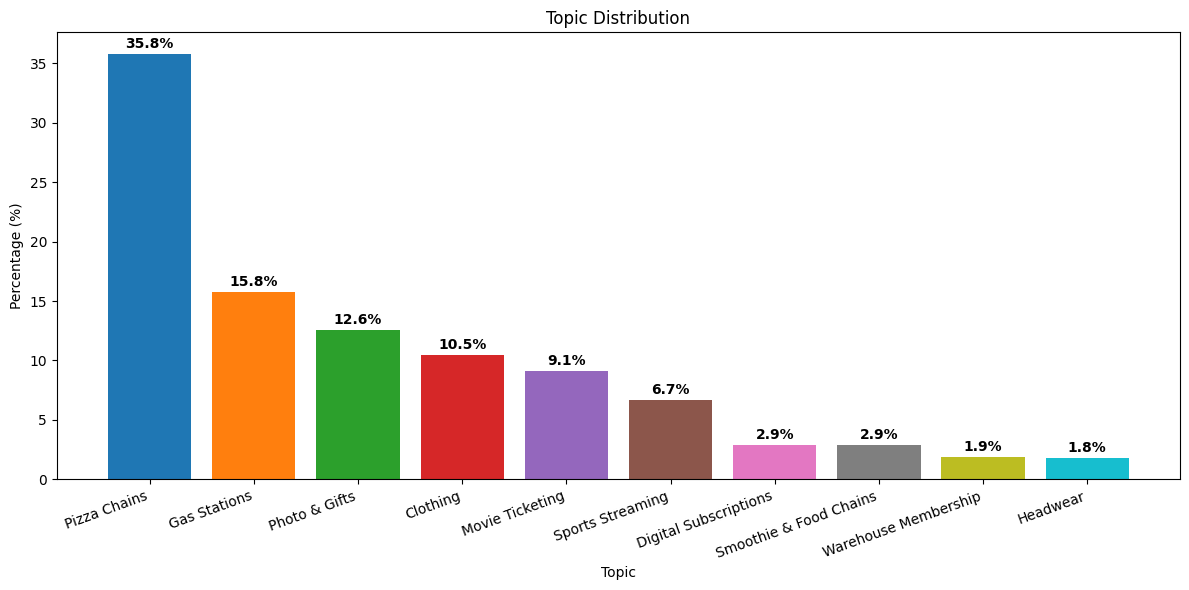

In [39]:
topic_counts = data['topic'].value_counts(dropna=True)
total = len(data)
topic_pct = (topic_counts / total * 100).round(1)

# Define a list of colors for the bar chart
colors = plt.cm.get_cmap('tab10', len(topic_counts)) # Using a colormap for distinct colors

plt.figure(figsize=(12, 6))
bars = plt.bar(topic_counts.index.astype(str), topic_pct.values, color=[colors(i) for i in range(len(topic_counts))])
plt.title('Topic Distribution')
plt.xlabel('Topic')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(topic_pct.values):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3l – Visualize Brand Frequency
Plot how often each individual brand appeared across all T-Mobile Tuesday offers.

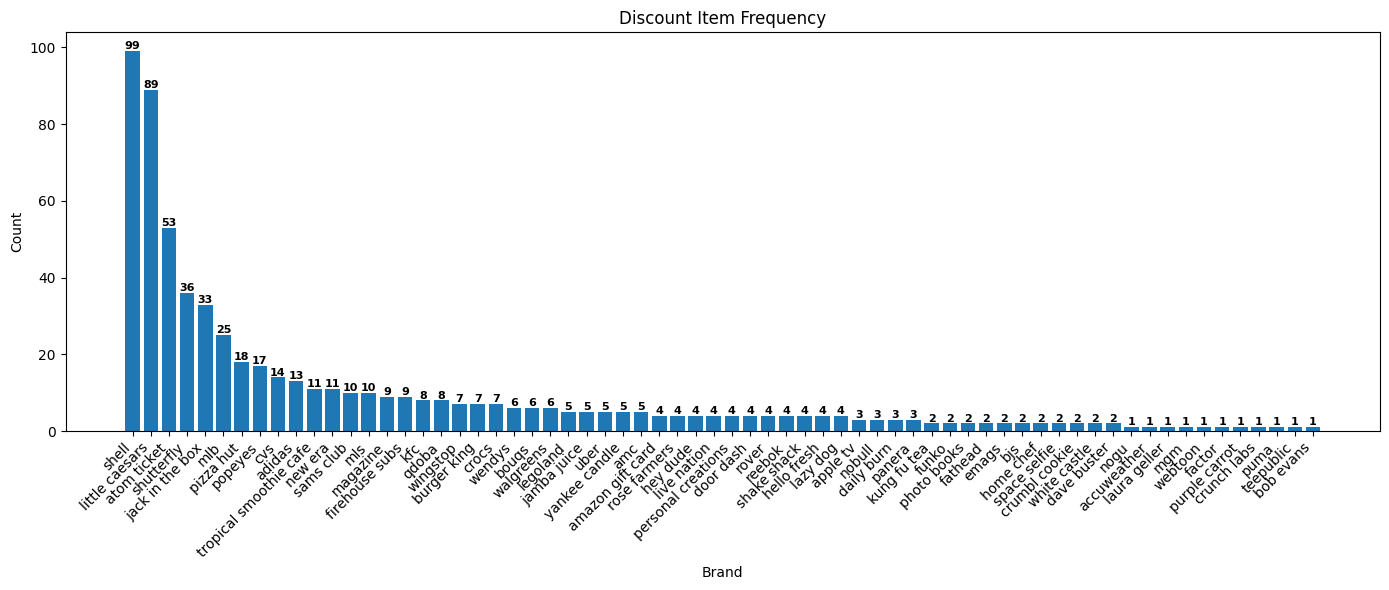

In [36]:
item_counts = data['brands'].value_counts()

plt.figure(figsize=(14, 6))
bars = plt.bar(item_counts.index.astype(str), item_counts.values, color='#1f77b4')
plt.title('Discount Item Frequency')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(item_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=8)
plt.tight_layout()
plt.show()